# exp005 baseline with target encoding

## 0. Experiment Metadata

In [22]:
# ========================================
# EXPERIMENT CONFIG
# ========================================

EXP_NAME = "exp005_target_encoding_baseline"
TARGET = "Churn"
ID_COL = "id"

N_SPLITS = 5
SEED = 42

print(f"Running {EXP_NAME}")

Running exp005_target_encoding_baseline


## 1. Imports

In [2]:
# ========================================
# IMPORTS
# ========================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',50)

## 2. Reproducibility

In [3]:
# ========================================
# SEED EVERYTHING
# ========================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

## 3. Load Data

In [12]:
# ========================================
# LOAD DATA
# ========================================

DATA_PATH = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")

print(train.shape, test.shape)
train.head()

(594194, 21) (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 4. Quick Sanity Checs (Fast EDA)

In [13]:
# ========================================
# QUICK EDA
# ========================================

print("Target distribution:")
print(train['Churn'].value_counts(normalize=True))

print("\nMissing values (top 10):")
print(train.isnull().mean().sort_values(ascending=False).head(10))

Target distribution:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

Missing values (top 10):
id                  0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
dtype: float64


## 5. Feature Engineering 

In [14]:
# ========================================
# FEATURE ENGINEERING
# ========================================

def create_features(df):
    df = df.copy()
    
    
    if "MonthlyCharges" in df.columns and "tenure" in df.columns:
        df["usage_velocity"] = df["MonthlyCharges"] / (df["tenure"] + 1)
    
    return df


train = create_features(train)
test = create_features(test)

## 6. Target Encoding

In [15]:
# ========================================
# TARGET ENCODING (SIMPLE VERSION)
# ========================================

from category_encoders import TargetEncoder

# Get categorical columns from TRAIN
categorical_cols = train.select_dtypes(include="object").columns.tolist()

# Remove target column
categorical_cols = [col for col in categorical_cols if col != TARGET]

# Initialize encoder
encoder = TargetEncoder(cols=categorical_cols)

# Fit on train, transform both
train[categorical_cols] = encoder.fit_transform(train[categorical_cols], train[TARGET])
test[categorical_cols] = encoder.transform(test[categorical_cols])

## 7. Prepare Data

In [16]:
# ========================================
# PREPARE DATA
# ========================================

features = [col for col in train.columns if col not in [TARGET, ID_COL]]

X = train[features]
y = train[TARGET]

X_test = test[features]

## 8. Validation Strategy

In [17]:
# ========================================
# CV SETUP
# ========================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

## 9. Model Training

In [18]:
# ========================================
# TRAINING LOOP
# ========================================

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    
    print(f"\n--- Fold {fold} ---")
    
    X_train, X_valid = X.iloc[tr_idx], X.iloc[val_idx]
    y_train, y_valid = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(100)   # 👈 replaces verbose=100
        ]
    )

    # Validation predictions
    val_preds = model.predict_proba(X_valid)[:, 1]
    oof_preds[val_idx] = val_preds

    # Test predictions
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

    score = roc_auc_score(y_valid, val_preds)
    scores.append(score)

    print(f"Fold {fold} AUC: {score:.5f}")

print("\nCV Mean:", np.mean(scores))
print("CV Std:", np.std(scores))


--- Fold 0 ---
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.303058
[200]	valid_0's binary_logloss: 0.300535
[300]	valid_0's binary_logloss: 0.299741
[400]	valid_0's binary_logloss: 0.299414
[500]	valid_0's binary_logloss: 0.299227
[600]	valid_0's binary_logloss: 0.299131
[700]	valid_0's binary_logloss: 0.2991
Early stopping, best iteration is:
[690]	valid_0's binary_logloss: 0.29909
Fol

## 10. Treshold Optimization

In [20]:
# ========================================
# THRESHOLD OPTIMIZATION (OOF)
# ========================================

from sklearn.metrics import f1_score
import numpy as np

# Make sure y is numeric
y_numeric = y.map({"No": 0, "Yes": 1}) if y.dtype == "object" else y

thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0.5
best_score = 0

for t in thresholds:
    preds_bin = (oof_preds > t).astype(int)
    score = f1_score(y_numeric, preds_bin)

    if score > best_score:
        best_score = score
        best_thresh = t

print("\nBest Threshold:", best_thresh)
print("Best F1 Score:", best_score)


Best Threshold: 0.34999999999999987
Best F1 Score: 0.7017901518331234


## 11. Feature Importance

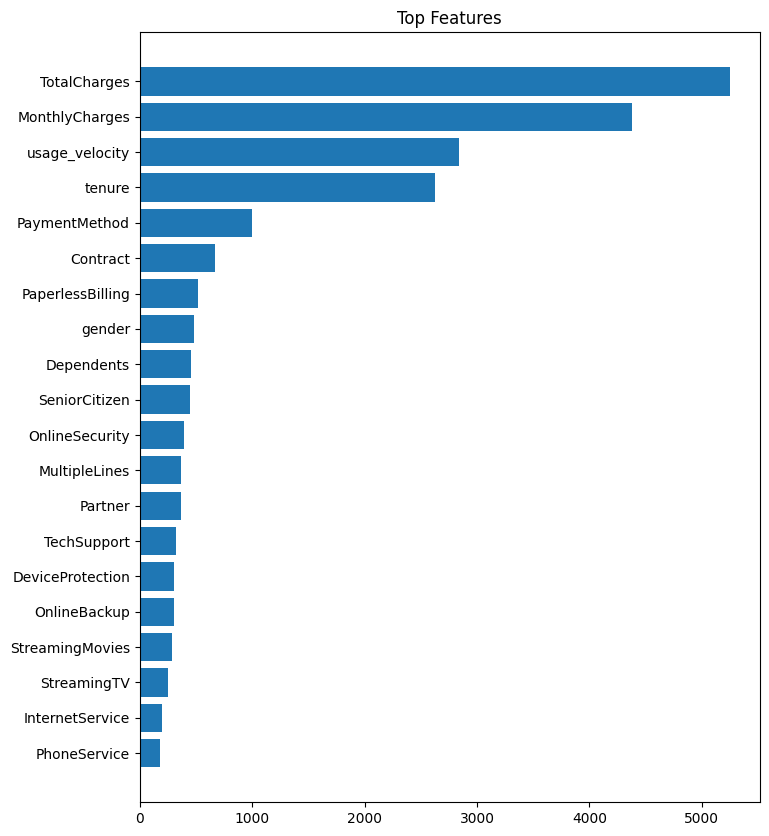

In [21]:
# ========================================
# FEATURE IMPORTANCE
# ========================================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(20)

plt.figure(figsize=(8, 10))
plt.barh(importance["feature"].head(20), importance["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

## 12. Create Submission

In [23]:
# ========================================
# SUBMISSION (SAVE TO CUSTOM PATH)
# ========================================

import os

# Define path
OUTPUT_DIR = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/"

# Create folder if not exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create submission
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: (test_preds > best_thresh).astype(int)  # or test_preds if using probability
})

# File path
file_path = os.path.join(OUTPUT_DIR, f"{EXP_NAME}.csv")

# Save
submission.to_csv(file_path, index=False)

print(f"Submission saved at: {file_path}")

Submission saved at: /Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/exp005_target_encoding_baseline.csv
